# Multi-Model Forecast Comparison

Run multiple AI weather models on the same date and compare their skill against ERA5 reanalysis.

**Extra installs:**
```
uv add earth2studio --extra sfno --extra pangu --extra fuxi --extra statistics
```

In [1]:
import os
from datetime import datetime

import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import earth2studio.run as run
from earth2studio.models.px import FCN, GraphCastOperational, SFNO, Pangu6, FuXi
from earth2studio.data import GFS, WB2ERA5
from earth2studio.io import ZarrBackend

/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


In [2]:
CONFIG = {
    "forecast_date": "2023-01-08",  # must be <= 2023 for ERA5 verification
    "nsteps": 4,
    "output_root": "outputs/model_comparison",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

os.makedirs(CONFIG["output_root"], exist_ok=True)
print(f"Device: {CONFIG['device']}")

Device: cuda


## Load Models and Data

In [3]:
# Load all models — adjust this list based on your GPU VRAM
# GraphCast and SFNO need ~16GB+, Pangu and FuXi are lighter
MODELS = {}

print("Loading FCN...")
MODELS["FCN"] = FCN.load_model(FCN.load_default_package())

# Uncomment models your GPU can handle:
print("Loading GraphCast...")
MODELS["GraphCast"] = GraphCastOperational.load_model(GraphCastOperational.load_default_package())

# print("Loading SFNO...")
# MODELS["SFNO"] = SFNO.load_model(SFNO.load_default_package())

# print("Loading Pangu6...")
# MODELS["Pangu6"] = Pangu6.load_model(Pangu6.load_default_package())

# print("Loading FuXi...")
# MODELS["FuXi"] = FuXi.load_model(FuXi.load_default_package())

gfs_data = GFS()
era5_data = WB2ERA5(cache=True, verbose=True)

print(f"Loaded {len(MODELS)} models: {list(MODELS.keys())}")

Loading FCN...
Loading GraphCast...
Loaded 2 models: ['FCN', 'GraphCast']


## Run Forecasts

In [4]:
zarr_paths = {}

model_loaders = {
    "FCN": lambda: FCN.load_model(FCN.load_default_package()),
    "GraphCast": lambda: GraphCastOperational.load_model(GraphCastOperational.load_default_package()),
}

for name, loader in model_loaders.items():
    print(f"Loading {name}...")
    model = loader()
    
    path = f"{CONFIG['output_root']}/{name.lower()}_forecast.zarr"
    io = ZarrBackend(path, backend_kwargs={"overwrite": True})
    
    print(f"Running {name}...")
    io = run.deterministic([CONFIG["forecast_date"]], CONFIG["nsteps"], model, gfs_data, io)
    zarr_paths[name] = path
    
    # Free GPU memory before loading next model
    del model
    torch.cuda.empty_cache()
    print(f"  {name} complete. VRAM freed.")

print(f"\nAll forecasts stored: {list(zarr_paths.keys())}")

Loading FCN...
Running FCN...
2026-04-06 23:24:21.879 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-06 23:24:21.879 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-06 23:24:22.056 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 259537113-913912
2026-04-06 23:24:22.084 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 205368789-588412


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-06 23:24:22.098 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 252352006-798963
2026-04-06 23:24:22.113 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 198756557-721074
2026-04-06 23:24:22.127 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 412830159-956677
2026-04-06 23:24:22.141 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 330406167-831548
2026-04-06 23:24:22.155 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253150969-714516
2026-04-06 23:24:22.169 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS 

...

2026-04-06 23:24:32.685 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 233622946-1115429
2026-04-06 23:24:32.687 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 274065313-794909
2026-04-06 23:24:32.688 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 212115461-1155730
2026-04-06 23:24:32.690 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 201403781-1138715
2026-04-06 23:24:32.691 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230108/00/atmos/gfs.t00z.pgrb2.0p25.f000 179412172-742944
2026-04-06 23:24:32.693 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching G

Fetching GFS data: 100%|██████████| 82/82 [00:02<00:00, 37.25it/s]


2026-04-06 23:24:34.989 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-06 23:24:35.129 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:  20%|██        | 1/5 [00:07<00:28,  7.03s/it]WARNING:absl:Skipping gradient checkpointing for sequence length of 1

Running inference: 100%|██████████| 5/5 [01:25<00:00, 17.09s/it]

2026-04-06 23:26:00.584 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
  GraphCast complete. VRAM freed.

All forecasts stored: ['FCN', 'GraphCast']


## Fetch ERA5 Verification Data

In [16]:
from scipy.interpolate import RegularGridInterpolator
from datetime import timedelta

first_model = list(zarr_paths.keys())[0]
ds_ref = xr.open_zarr(zarr_paths[first_model])
lats = ds_ref["lat"].values   # 721 points, 90 -> -90 (descending)
lons = ds_ref["lon"].values   # 1440 points
n_steps = ds_ref.sizes["lead_time"]

start = datetime.strptime(CONFIG["forecast_date"], "%Y-%m-%d")

def regrid_to_forecast(field, src_lats, src_lons, dst_lats, dst_lons):
    """Bilinearly interpolate a 2D field onto the forecast grid."""
    # RegularGridInterpolator requires ascending coords
    if src_lats[0] > src_lats[-1]:
        field = field[::-1, :]
        src_lats = src_lats[::-1]
    interp = RegularGridInterpolator(
        (src_lats, src_lons), field,
        method="linear", bounds_error=False, fill_value=None
    )
    # dst_lats may be descending (90 -> -90) — meshgrid handles it fine
    lon_2d, lat_2d = np.meshgrid(dst_lons, dst_lats)
    return interp((lat_2d, lon_2d))

# Fetch ERA5 t2m at each valid time
era5_t2m_raw = []
era5_lats = None
era5_lons = None

for s in range(n_steps):
    valid_time = start + timedelta(hours=6 * s)
    da = era5_data(valid_time, ["t2m"])
    if era5_lats is None:
        era5_lats = da["lat"].values
        era5_lons = da["lon"].values
    era5_t2m_raw.append(da.values.squeeze())

era5_t2m_raw = np.stack(era5_t2m_raw, axis=0)
print(f"ERA5 raw shape:      {era5_t2m_raw.shape}")
print(f"Forecast grid shape: ({len(lats)}, {len(lons)})")

# Always regrid onto forecast grid
era5_t2m = np.stack([
    regrid_to_forecast(era5_t2m_raw[s], era5_lats.copy(), era5_lons.copy(), lats, lons)
    for s in range(n_steps)
], axis=0)

print(f"ERA5 regridded shape: {era5_t2m.shape}")
assert era5_t2m.shape == (n_steps, len(lats), len(lons)), "Regrid shape mismatch!"

Fetching WB2 data: 100%|██████████| 1/1 [00:00<00:00, 159.13it/s]


2026-04-06 23:33:18.468 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t2m at 2023-01-08T00:00:00


Fetching WB2 data: 100%|██████████| 1/1 [00:00<00:00, 176.05it/s]


2026-04-06 23:33:18.476 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t2m at 2023-01-08T06:00:00


Fetching WB2 data: 100%|██████████| 1/1 [00:00<00:00, 181.42it/s]


2026-04-06 23:33:18.484 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t2m at 2023-01-08T12:00:00


Fetching WB2 data: 100%|██████████| 1/1 [00:00<00:00, 188.18it/s]


2026-04-06 23:33:18.492 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t2m at 2023-01-08T18:00:00


Fetching WB2 data: 100%|██████████| 1/1 [00:00<00:00, 145.02it/s]


2026-04-06 23:33:18.500 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t2m at 2023-01-09T00:00:00
ERA5 raw shape:      (5, 721, 1440)
Forecast grid shape: (720, 1440)
ERA5 regridded shape: (5, 720, 1440)


## Side-by-Side T2M Comparison

TypeError: Dimensions of C (721, 1440) should be one smaller than X(1441) and Y(720) while using shading='flat' see help(pcolormesh)

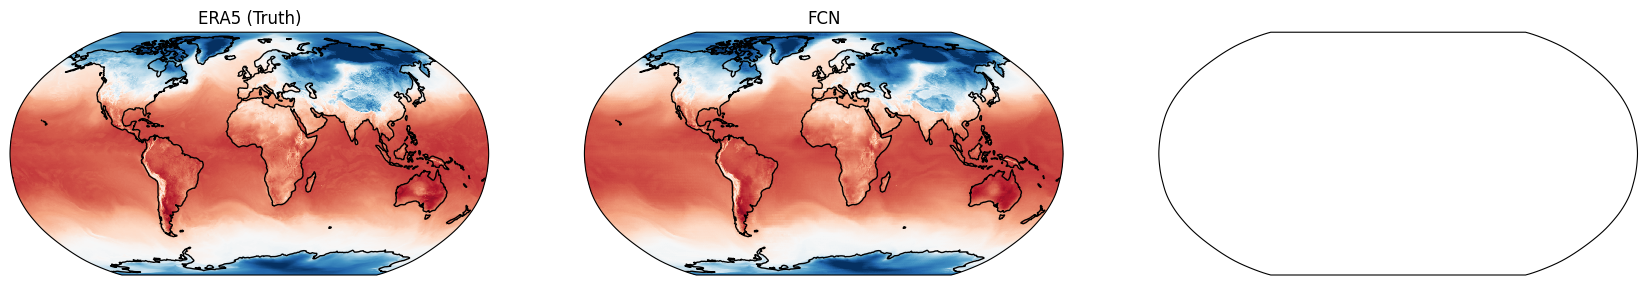

In [17]:
step = 4  # +24h

model_names = list(zarr_paths.keys())
n_models = len(model_names)
ncols = min(n_models + 1, 3)
nrows = (n_models + 1 + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows),
    subplot_kw={"projection": ccrs.Robinson()})
axes = list(np.array(axes).flat)

# ERA5 truth
era5_c = era5_t2m[step] - 273.15
im = axes[0].pcolormesh(lons, lats, era5_c, transform=ccrs.PlateCarree(),
                         cmap="RdBu_r", vmin=-40, vmax=40, shading="nearest")
axes[0].coastlines()
axes[0].set_title("ERA5 (Truth)", fontsize=12)

# Each model
for i, name in enumerate(model_names):
    ds = xr.open_zarr(zarr_paths[name])
    t2m_c = ds["t2m"].isel(time=0, lead_time=step).values - 273.15
    axes[i + 1].pcolormesh(lons, lats, t2m_c, transform=ccrs.PlateCarree(),
                            cmap="RdBu_r", vmin=-40, vmax=40, shading="nearest")
    axes[i + 1].coastlines()
    axes[i + 1].set_title(name, fontsize=12)

# Hide unused axes
for j in range(n_models + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"T2M Comparison — +{step*6}h  |  Init: {CONFIG['forecast_date']}", fontsize=14)
cbar = fig.colorbar(im, ax=axes[:n_models + 1], orientation="horizontal",
                    pad=0.06, shrink=0.5, label="2m Temperature (°C)")
plt.savefig(f"{CONFIG['output_root']}/t2m_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Error Maps (Model - ERA5)

ValueError: operands could not be broadcast together with shapes (721,1440) (720,1440) 

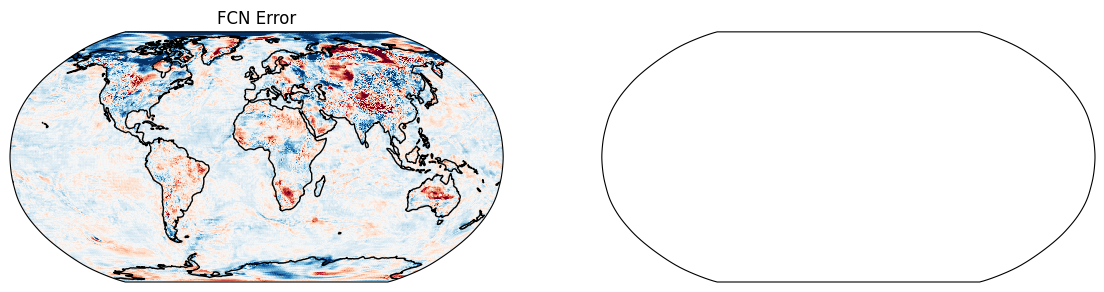

In [12]:
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6),
    subplot_kw={"projection": ccrs.Robinson()})
if n_models == 1:
    axes = [axes]

for i, name in enumerate(model_names):
    ds = xr.open_zarr(zarr_paths[name])
    t2m_model = ds["t2m"].isel(time=0, lead_time=step).values  # (721, 1440)
    error = t2m_model - era5_t2m[step]                         # (721, 1440)

    im = axes[i].pcolormesh(lons, lats, error, transform=ccrs.PlateCarree(),
                             cmap="RdBu_r", vmin=-5, vmax=5, shading="nearest")
    axes[i].coastlines()
    axes[i].set_title(f"{name} Error", fontsize=12)

fig.suptitle(f"T2M Forecast Error — +{step*6}h", fontsize=14)
cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    pad=0.06, shrink=0.5, label="Error (K)")
plt.savefig(f"{CONFIG['output_root']}/error_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## RMSE vs Lead Time

ValueError: operands could not be broadcast together with shapes (721,1440) (720,1440) 

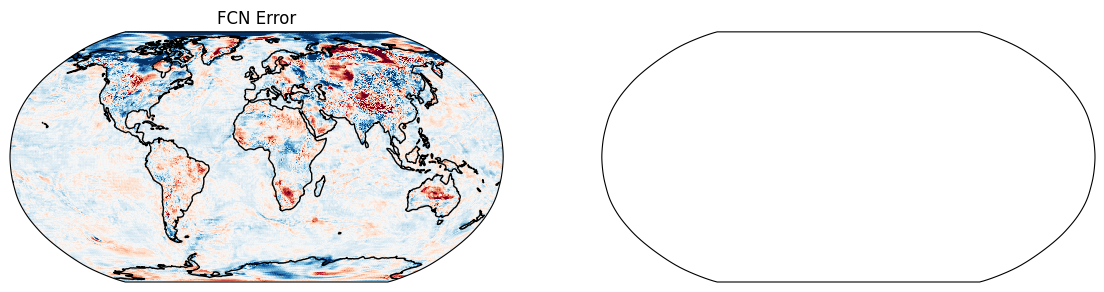

In [18]:
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6),
    subplot_kw={"projection": ccrs.Robinson()})
if n_models == 1:
    axes = [axes]

for i, name in enumerate(model_names):
    ds = xr.open_zarr(zarr_paths[name])
    t2m_model = ds["t2m"].isel(time=0, lead_time=step).values  # (721, 1440)
    error = t2m_model - era5_t2m[step]                         # (721, 1440)

    im = axes[i].pcolormesh(lons, lats, error, transform=ccrs.PlateCarree(),
                             cmap="RdBu_r", vmin=-5, vmax=5, shading="nearest")
    axes[i].coastlines()
    axes[i].set_title(f"{name} Error", fontsize=12)

fig.suptitle(f"T2M Forecast Error — +{step*6}h", fontsize=14)
cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    pad=0.06, shrink=0.5, label="Error (K)")
plt.savefig(f"{CONFIG['output_root']}/error_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## Multi-Variable Comparison at +48h

In [20]:
variables = ["t2m", "z500", "u10m"]
step_48h = 8  # +48h

# Compute RMSE for each model x variable
results = {name: {} for name in model_names}

for name in model_names:
    ds = xr.open_zarr(zarr_paths[name])
    for var in variables:
        if var in ds.data_vars:
            model_field = ds[var].isel(time=0, lead_time=step_48h).values
            # Fetch ERA5 for this variable
            era5_var = era5_data(
                start + timedelta(hours=6 * step_48h), [var]
            ).values.squeeze()
            results[name][var] = compute_rmse(model_field, era5_var)
        else:
            results[name][var] = np.nan

# Grouped bar chart
x = np.arange(len(variables))
width = 0.8 / len(model_names)

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(model_names):
    vals = [results[name].get(v, np.nan) for v in variables]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i])

ax.set_xlabel("Variable")
ax.set_ylabel("RMSE")
ax.set_title(f"RMSE at +48h by Variable  |  Init: {CONFIG['forecast_date']}")
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(variables)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_root']}/multi_variable_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

IndexError: Index 8 is out of bounds for axis 1 with size 5

## Summary Table

In [21]:
import pandas as pd

rows = []
for name in model_names:
    row = {"Model": name}
    for var in variables:
        row[f"{var} RMSE"] = f"{results[name].get(var, np.nan):.3f}"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Model")
print(df.to_string())
df

          t2m RMSE z500 RMSE u10m RMSE
Model                                 
FCN            nan       nan       nan
GraphCast      nan       nan       nan


,t2m RMSE,z500 RMSE,u10m RMSE
Model,,,
FCN,nan,nan,nan
GraphCast,nan,nan,nan
